### Практическая работа №4: Деревья решений

Выполнил: Чашин Денис, ЕТ-128

In [16]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

In [17]:
# Загрузка датасета Iris (Цветы ириса)
iris = datasets.load_iris()
X = iris.data
# X = X + np.random.normal(0, 0.5, X.shape)
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Краткая сводка по данным
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris["target"] = y
df_iris["species"] = df_iris["target"].map({i: name for i, name in enumerate(iris.target_names)})

print("Размерность X:", X.shape)
print("Классы:", list(iris.target_names))
print("\nПервые 5 строк:")
df_iris.head()

Размерность X: (150, 4)
Классы: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Первые 5 строк:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [18]:
ratio_train = list(range(60, 95, 5))

criteria = ['gini', 'entropy']

model_metrics = {
    'gini': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
    'entropy': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
}

tree_models = {'gini': [], 'entropy': []}

In [19]:
for criterion in criteria:
    for tr in ratio_train:
        ratio = tr / 100
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=ratio, random_state=42, stratify=y
        )

        model = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=None,
            random_state=42
        )
        model.fit(X_train, y_train)

        tree_models[criterion].append(model)

        y_pred = model.predict(X_test)

        model_metrics[criterion]['accuracy'].append(accuracy_score(y_test, y_pred))
        model_metrics[criterion]['precision'].append(precision_score(y_test, y_pred, average='macro'))
        model_metrics[criterion]['recall'].append(recall_score(y_test, y_pred, average='macro'))
        model_metrics[criterion]['f1'].append(f1_score(y_test, y_pred, average='macro'))

In [20]:
tables = {}

for criterion in criteria:
    df = pd.DataFrame({
        "Train/Test": [f"{tr}% / {100-tr}%" for tr in ratio_train],
        "Accuracy": model_metrics[criterion]["accuracy"],
        "Precision (macro)": model_metrics[criterion]["precision"],
        "Recall (macro)": model_metrics[criterion]["recall"],
        "F1-score (macro)": model_metrics[criterion]["f1"],
    })
    tables[criterion] = df

    print(f"\nКритерий: {criterion.upper()}")
    display(df.style.format({
        "Accuracy": "{:.4f}",
        "Precision (macro)": "{:.4f}",
        "Recall (macro)": "{:.4f}",
        "F1-score (macro)": "{:.4f}",
    }))



Критерий: GINI


,Train/Test,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,60% / 40%,0.9500,0.9507,0.9500,0.9500
1,65% / 35%,0.9434,0.9453,0.9444,0.9444
2,70% / 30%,0.9333,0.9444,0.9333,0.9327
3,75% / 25%,0.8947,0.9030,0.8974,0.8968
4,80% / 20%,0.9333,0.9333,0.9333,0.9333
5,85% / 15%,0.9130,0.9167,0.9167,0.9167
6,90% / 10%,0.8667,0.8667,0.8667,0.8667



Критерий: ENTROPY


,Train/Test,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,60% / 40%,0.9500,0.9507,0.9500,0.9500
1,65% / 35%,0.9434,0.9453,0.9444,0.9444
2,70% / 30%,0.8889,0.8899,0.8889,0.8888
3,75% / 25%,0.8947,0.9030,0.8974,0.8968
4,80% / 20%,0.9333,0.9333,0.9333,0.9333
5,85% / 15%,0.9130,0.9167,0.9167,0.9167
6,90% / 10%,0.8667,0.8667,0.8667,0.8667


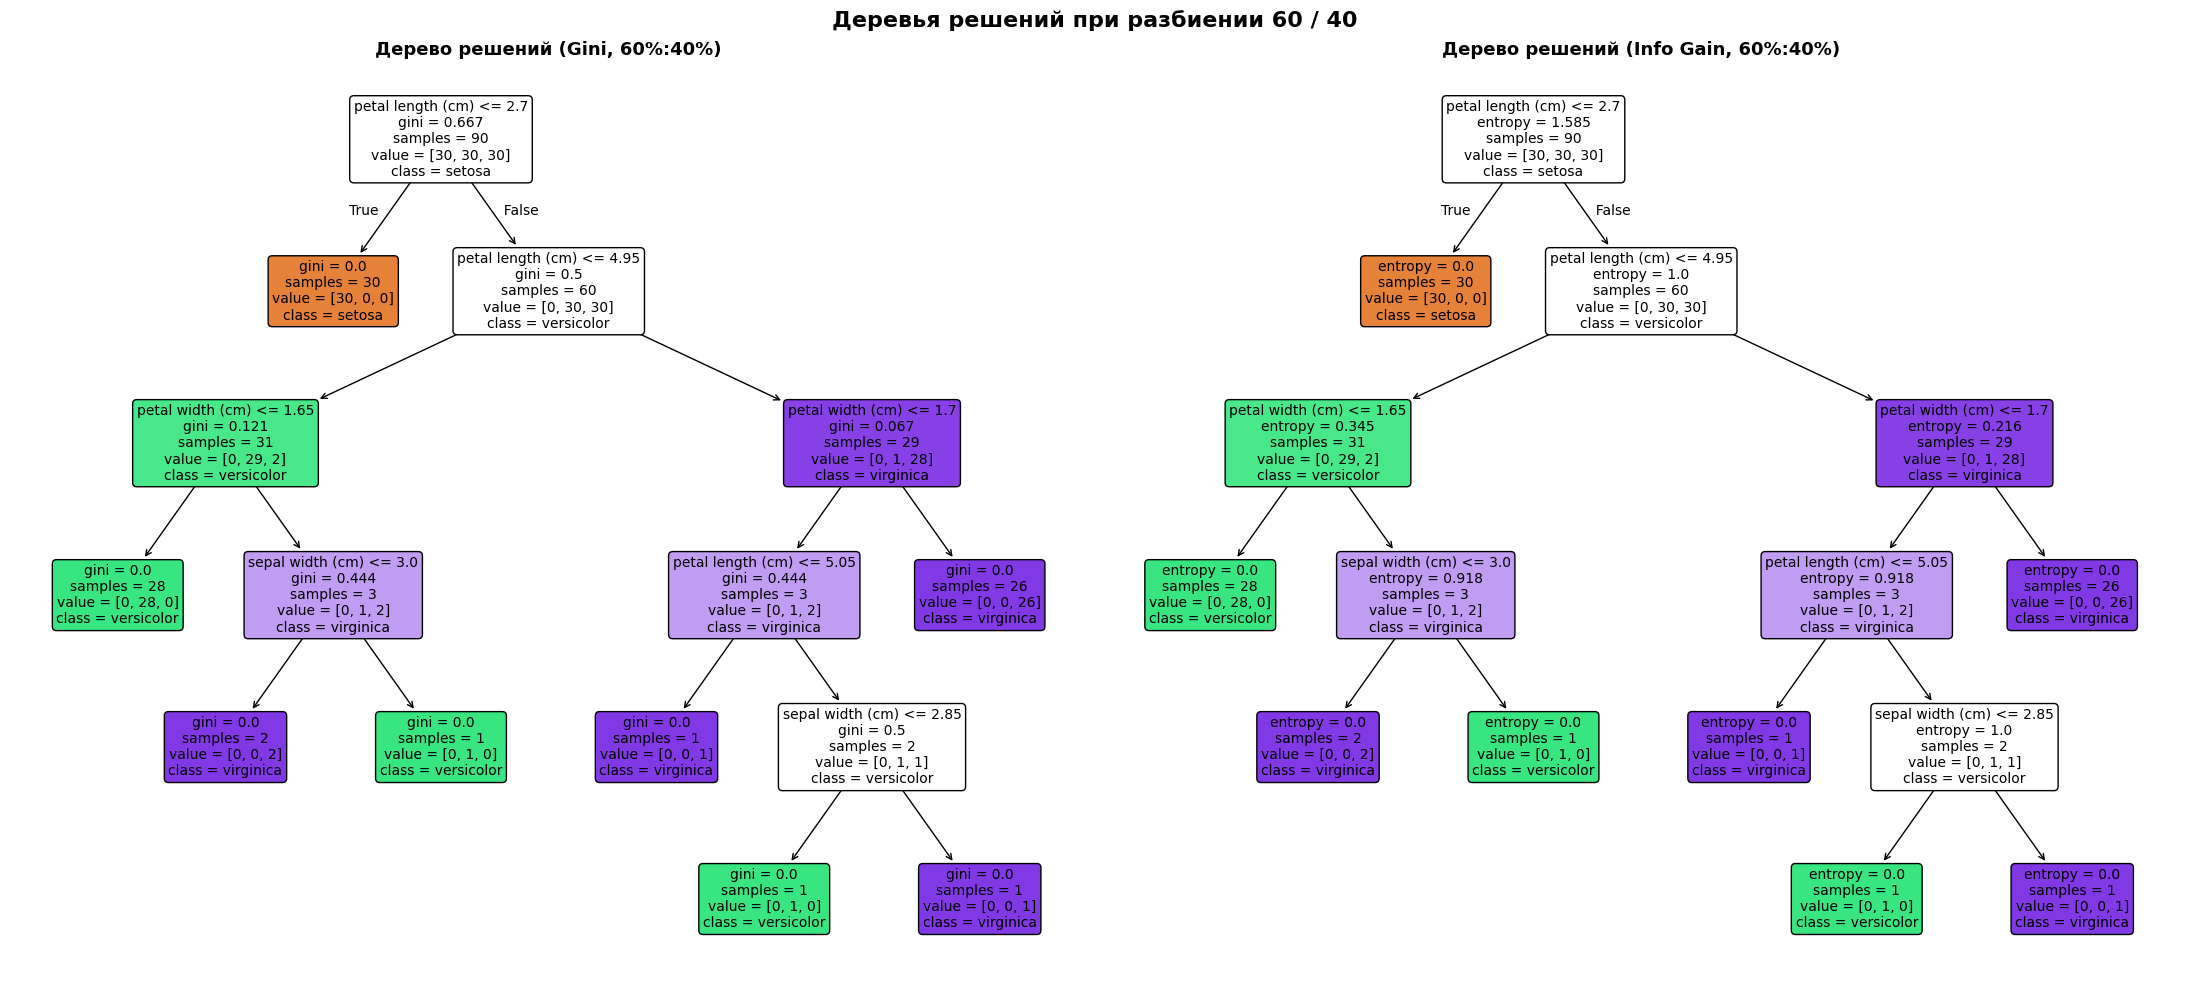

In [21]:
# Индекс для 60%
idx_60 = 0

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

titles_60 = [
    f'Дерево решений (Gini, 60%:{100 - ratio_train[idx_60]}%)',
    f'Дерево решений (Info Gain, 60%:{100 - ratio_train[idx_60]}%)'
]

criteria_60 = ['gini', 'entropy']

for ax, crit, title in zip(axes, criteria_60, titles_60):
    plot_tree(
        tree_models[crit][idx_60],
        feature_names=feature_names,
        class_names=target_names,
        filled=True,
        rounded=True,
        fontsize=10,
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle("Деревья решений при разбиении 60 / 40",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

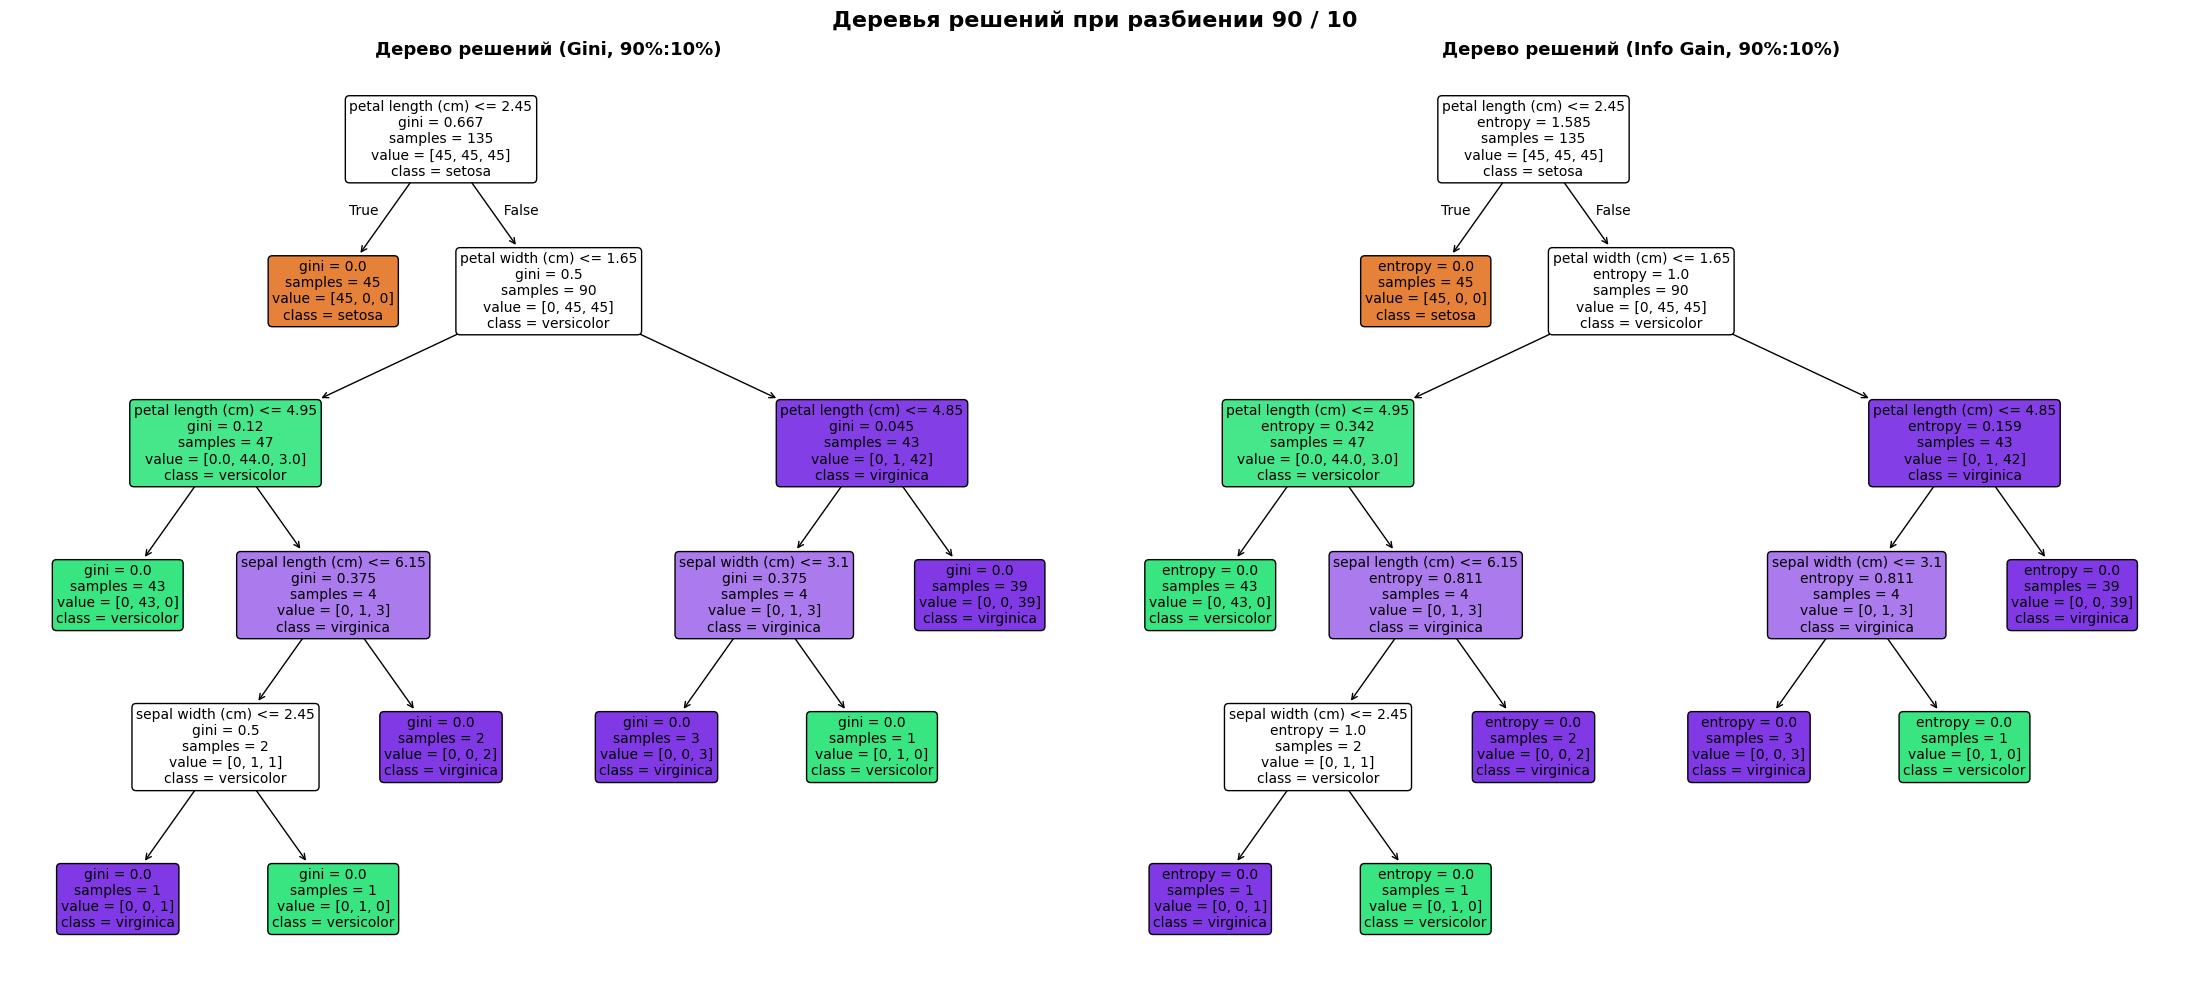

In [22]:
# Индекс для 90%
idx_90 = -1

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

titles_90 = [
    f'Дерево решений (Gini, 90%:{100 - ratio_train[idx_90]}%)',
    f'Дерево решений (Info Gain, 90%:{100 - ratio_train[idx_90]}%)'
]

criteria_90 = ['gini', 'entropy']

for ax, crit, title in zip(axes, criteria_90, titles_90):
    plot_tree(
        tree_models[crit][idx_90],
        feature_names=feature_names,
        class_names=target_names,
        filled=True,
        rounded=True,
        fontsize=10,
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle("Деревья решений при разбиении 90 / 10",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

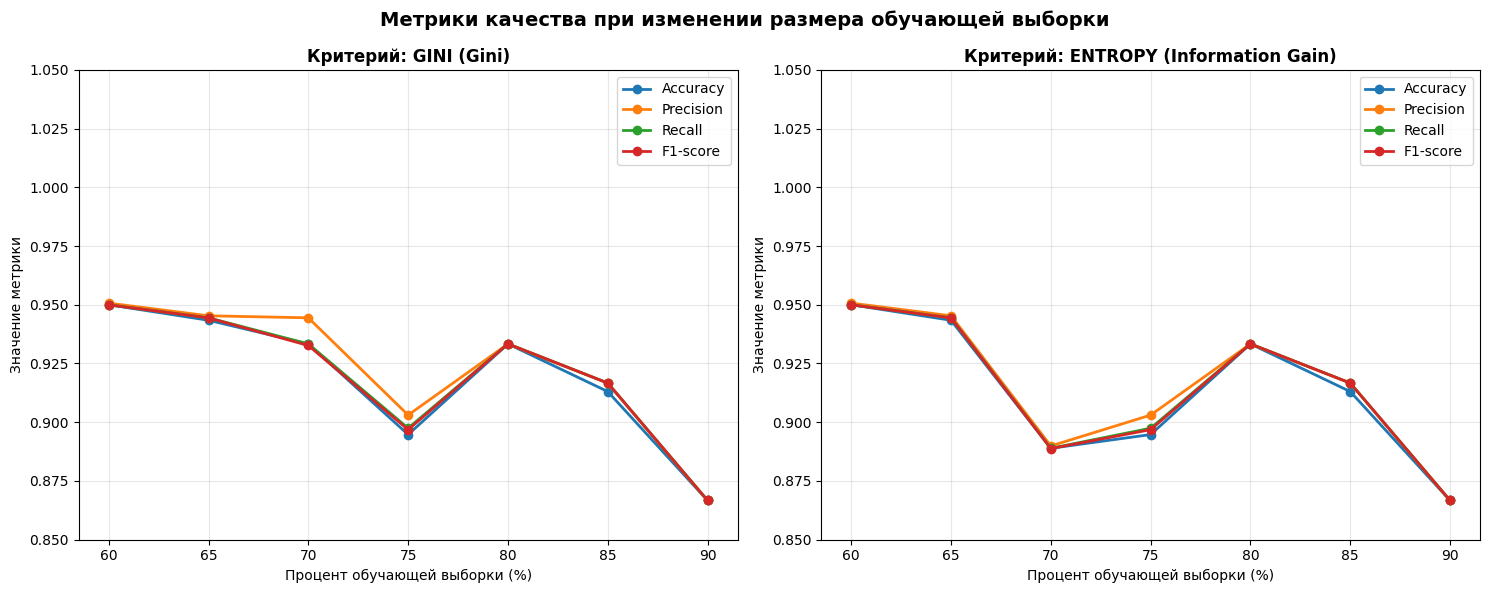

In [23]:
# График всех метрик для обоих критериев
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, criterion in enumerate(criteria):
    ax = axes[idx]

    ax.plot(ratio_train, model_metrics[criterion]['accuracy'], marker='o', linewidth=2, label='Accuracy')
    ax.plot(ratio_train, model_metrics[criterion]['precision'], marker='o', linewidth=2, label='Precision')
    ax.plot(ratio_train, model_metrics[criterion]['recall'], marker='o', linewidth=2, label='Recall')
    ax.plot(ratio_train, model_metrics[criterion]['f1'], marker='o', linewidth=2, label='F1-score')

    ax.set_title(f'Критерий: {criterion.upper()} {"(Gini)" if criterion=="gini" else "(Information Gain)"}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Процент обучающей выборки (%)", fontsize=10)
    ax.set_ylabel("Значение метрики", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xticks(ratio_train)
    ax.set_ylim(0.85, 1.05)

plt.suptitle("Метрики качества при изменении размера обучающей выборки",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

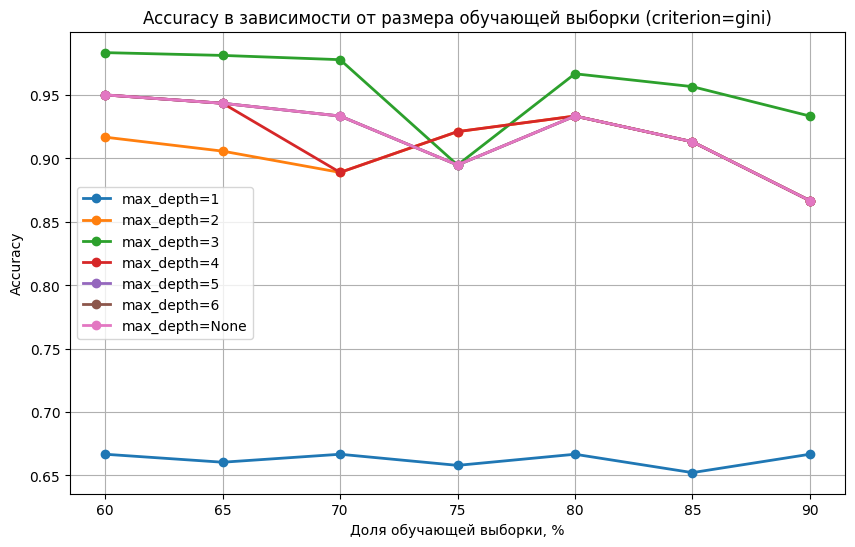

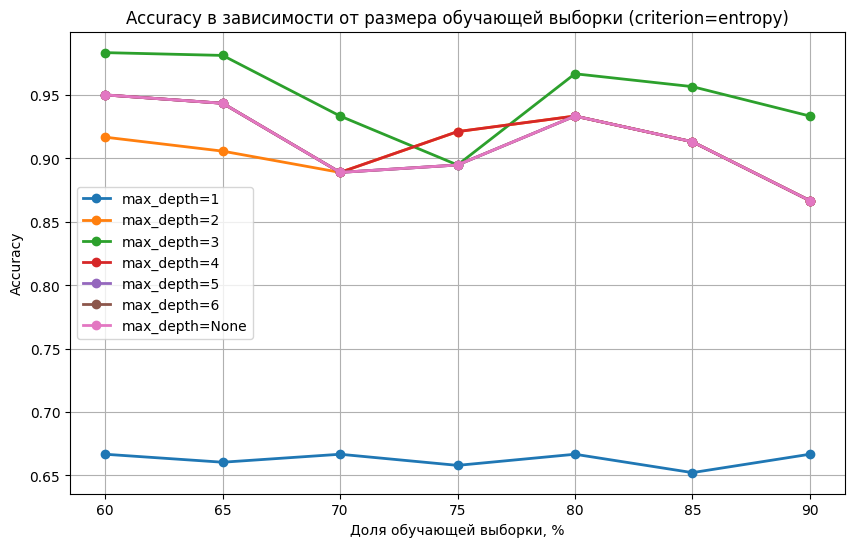

In [24]:
# Accuracy для деревьев решений разной длины
depths = [1, 2, 3, 4, 5, 6, None]

depth_acc = {criterion: {d: [] for d in depths} for criterion in criteria}

for criterion in criteria:
    for tr in ratio_train:
        ratio = tr / 100
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=ratio, random_state=42, stratify=y
        )

        for d in depths:
            model = DecisionTreeClassifier(criterion=criterion, max_depth=d, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            depth_acc[criterion][d].append(accuracy_score(y_test, y_pred))

for criterion in criteria:
    plt.figure(figsize=(10, 6))
    for d in depths:
        label = f"max_depth={d}" if d is not None else "max_depth=None"
        plt.plot(ratio_train, depth_acc[criterion][d], marker='o', linewidth=2, label=label)

    plt.title(f"Accuracy в зависимости от размера обучающей выборки (criterion={criterion})")
    plt.xlabel("Доля обучающей выборки, %")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()
